<a href="https://colab.research.google.com/github/Julfikar-Asif/Investigating-Netflix-Movies/blob/main/Investigating_Netflix_Movies.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [58]:
import pandas as pd

# Load the dataset
netflix_df = pd.read_csv('/content/netflix_data.csv')

# Filter for movies released in the 1990s (1990-1999)
# Assuming the column name for release year is 'release_year' and type is 'Movie'
movies_1990s = netflix_df[(netflix_df['release_year'] >= 1990) & (netflix_df['release_year'] < 2000) & (netflix_df['type'] == 'Movie')]

display(movies_1990s.head())

,show_id,type,title,director,cast,country,date_added,release_year,duration,description,genre
6,s8,Movie,187,Kevin Reynolds,"Samuel L. Jackson, John Heard, Kelly Rowan, Cl...",United States,"November 1, 2019",1997,119,After one of his high school students attacks ...,Dramas
118,s167,Movie,A Dangerous Woman,Stephen Gyllenhaal,"Debra Winger, Barbara Hershey, Gabriel Byrne, ...",United States,"April 1, 2018",1993,101,At the center of this engrossing melodrama is ...,Dramas
145,s211,Movie,A Night at the Roxbury,John Fortenberry,"Will Ferrell, Chris Kattan, Dan Hedaya, Molly ...",United States,"December 1, 2019",1998,82,"After a run-in with Richard Grieco, dimwits Do...",Comedies
167,s239,Movie,A Thin Line Between Love & Hate,Martin Lawrence,"Martin Lawrence, Lynn Whitfield, Regina King, ...",United States,"December 1, 2020",1996,108,When a philandering club promoter sets out to ...,Comedies
194,s274,Movie,Aashik Awara,Umesh Mehra,"Saif Ali Khan, Mamta Kulkarni, Mohnish Bahl, S...",India,"June 1, 2017",1993,154,"Raised by a kindly thief, orphaned Jimmy goes ...",Dramas


In [59]:
# Find the most frequent movie duration in the 1990s
duration = int(movies_1990s['duration'].mode()[0])

print(f"The most frequent movie duration in the 1990s was: {duration} minutes")

The most frequent movie duration in the 1990s was: 94 minutes


In [60]:
# Filter for action movies in the 1990s
# Assuming the genre column is 'genre'
action_movies_1990s = movies_1990s[movies_1990s['genre'] == 'Action']

# Count short action movies (less than 90 minutes)
short_movie_count = int(action_movies_1990s[action_movies_1990s['duration'] < 90].shape[0])

print(f"Number of short action movies in the 1990s: {short_movie_count}")

Number of short action movies in the 1990s: 7


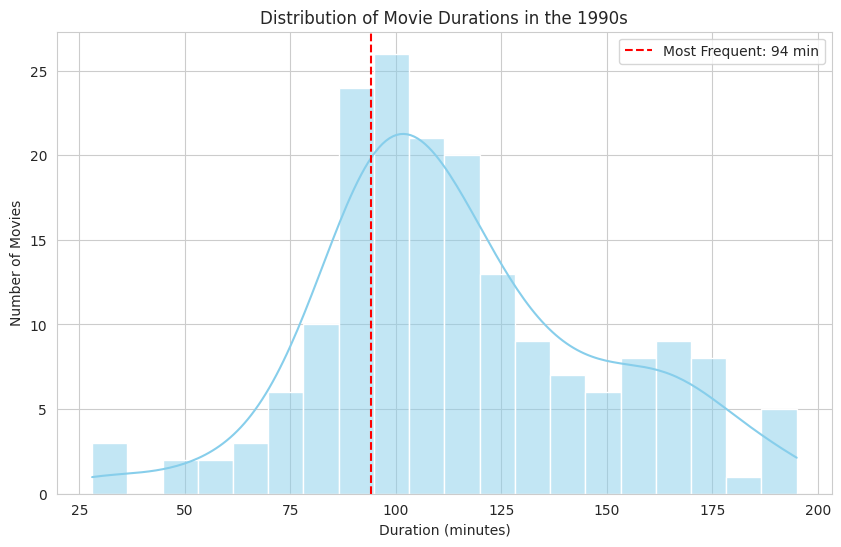

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style
sns.set_style('whitegrid')

# Plot the distribution of movie durations in the 1990s
plt.figure(figsize=(10, 6))
sns.histplot(movies_1990s['duration'], bins=20, kde=True, color='skyblue')
plt.title('Distribution of Movie Durations in the 1990s')
plt.xlabel('Duration (minutes)')
plt.ylabel('Number of Movies')
plt.axvline(duration, color='red', linestyle='--', label=f'Most Frequent: {duration} min')
plt.legend()
plt.show()

,decade,duration
0,1940,51.400000
1,1950,107.090909
2,1960,144.250000
3,1970,119.083333
4,1980,113.557895
5,1990,115.120219
6,2000,113.424448
7,2010,99.797980
8,2020,94.270115


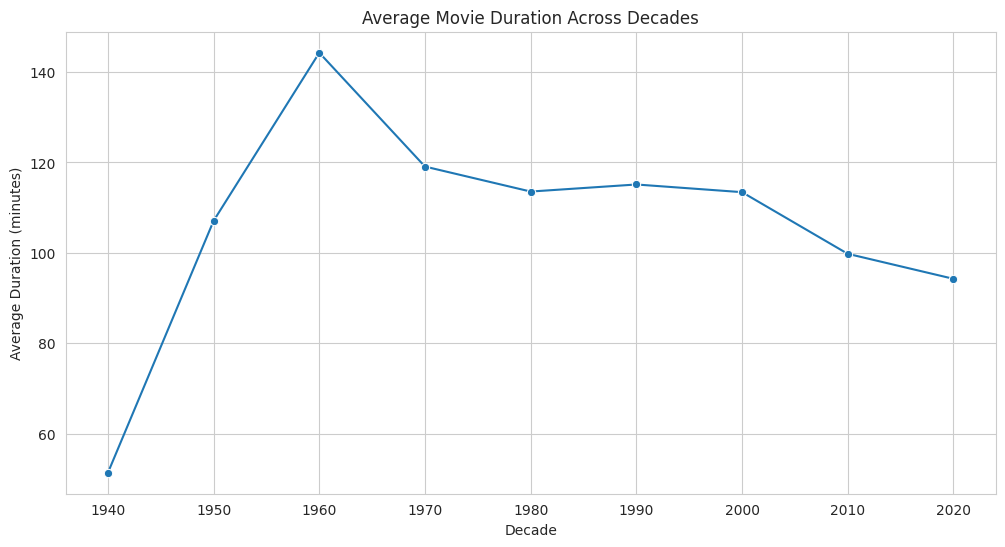

In [62]:
# Create a decade column
netflix_df['decade'] = (netflix_df['release_year'] // 10) * 10

# Filter for movies only
all_movies = netflix_df[netflix_df['type'] == 'Movie']

# Calculate average duration per decade
decade_avg = all_movies.groupby('decade')['duration'].mean().reset_index()

# Display the results
display(decade_avg)

# Visualize the trend
plt.figure(figsize=(12, 6))
sns.lineplot(data=decade_avg, x='decade', y='duration', marker='o')
plt.title('Average Movie Duration Across Decades')
plt.xlabel('Decade')
plt.ylabel('Average Duration (minutes)')
plt.grid(True)
plt.show()

In [63]:
# Count the number of movies per genre in the 1990s
genre_counts = movies_1990s['genre'].value_counts().reset_index()
genre_counts.columns = ['genre', 'count']

display(genre_counts)

,genre,count
0,Action,48
1,Dramas,44
2,Comedies,40
3,Children,15
4,Classic Movies,15
5,Stand-Up,8
6,Thrillers,5
7,Horror Movies,4
8,Documentaries,2
9,Cult Movies,2


In [64]:
# Filter for Action movies
action_movies = netflix_df[netflix_df['genre'] == 'Action']

# Count movies per director, excluding nulls
top_action_director = action_movies['director'].value_counts().head(1)

if not top_action_director.empty:
    director_name = top_action_director.index[0]
    movie_count = top_action_director.values[0]
    print(f"The director with the most Action movies is {director_name} with {movie_count} movies.")
else:
    print("No director information found for Action movies.")

The director with the most Action movies is Don Michael Paul with 6 movies.


In [65]:
# Identify the top 5 most frequent genres in the entire dataset
top_5_genres = netflix_df['genre'].value_counts().head(5).reset_index()
top_5_genres.columns = ['genre', 'count']

print("Top 5 most frequent genres in the dataset:")
display(top_5_genres)

Top 5 most frequent genres in the dataset:


,genre,count
0,Dramas,1343
1,Comedies,1029
2,Action,696
3,Children,421
4,Documentaries,352


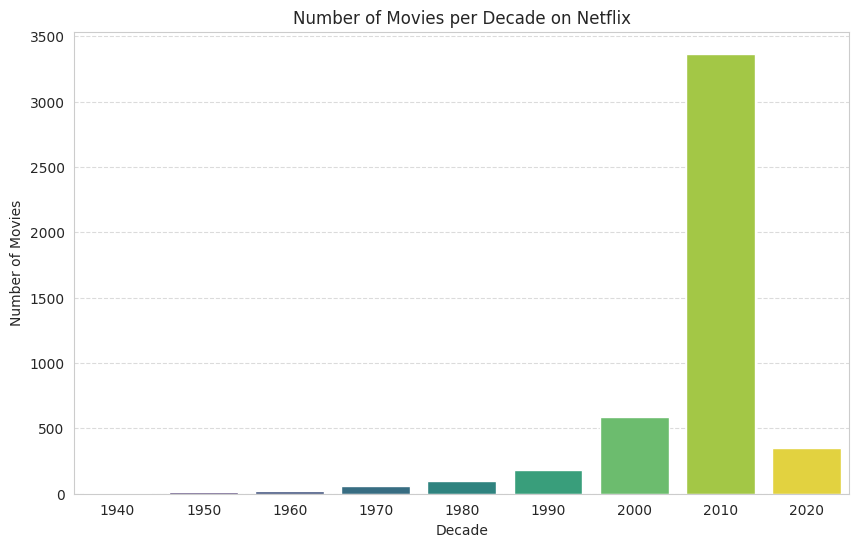

,decade,count
0,1940,5
1,1950,11
2,1960,20
3,1970,60
4,1980,95
5,1990,183
6,2000,589
7,2010,3366
8,2020,348


In [66]:
# Count the number of movies per decade
movie_counts_decade = all_movies['decade'].value_counts().sort_index().reset_index()
movie_counts_decade.columns = ['decade', 'count']

# Create the bar chart
plt.figure(figsize=(10, 6))
sns.barplot(data=movie_counts_decade, x='decade', y='count', palette='viridis', hue='decade', legend=False)
plt.title('Number of Movies per Decade on Netflix')
plt.xlabel('Decade')
plt.ylabel('Number of Movies')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Display the raw counts
display(movie_counts_decade)

In [67]:
import os

# Create a Streamlit app file
with open('app.py', 'w') as f:
    f.write('''
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

st.title("Netflix Movie Trends Analysis")

# Load data
@st.cache_data
def load_data():
    df = pd.read_csv('/content/netflix_data.csv')
    df['decade'] = (df['release_year'] // 10) * 10
    return df

df = load_data()

st.header("Key Statistics")
col1, col2 = st.columns(2)
with col1:
    st.metric("Top Genre", "Dramas")
with col2:
    st.metric("Peak Year", "2017")

st.subheader("Average Movie Duration per Decade")
decade_avg = df[df['type'] == 'Movie'].groupby('decade')['duration'].mean().reset_index()
fig, ax = plt.subplots()
sns.lineplot(data=decade_avg, x='decade', y='duration', marker='o', ax=ax)
st.pyplot(fig)

st.subheader("Top 5 Genres")
top_5 = df['genre'].value_counts().head(5)
st.bar_chart(top_5)
''')

print('Streamlit app file created as app.py')

Streamlit app file created as app.py


### Steps for Permanent Hosting on Streamlit Cloud

1. **Create a GitHub Repository:** Upload `app.py`, `netflix_data.csv`, and a `requirements.txt` file.
2. **Create requirements.txt:** This file should contain:
   ```text
   pandas
   matplotlib
   seaborn
   streamlit
   ```
3. **Deploy:** Go to [Streamlit Cloud](https://share.streamlit.io/), sign in with GitHub, and select your repository.
4. **Get a Permanent URL:** Streamlit will provide a consistent link (e.g., `https://your-app-name.streamlit.app`) that stays active 24/7.

In [69]:
!curl ipv4.icanhazip.com

34.125.110.210


In [70]:
# Sort movies by duration in descending order and select the top 5
longest_movies = all_movies.sort_values(by='duration', ascending=False).head(5)

# Display the selected movies with relevant columns
display(longest_movies[['title', 'director', 'release_year', 'duration', 'genre']])

,title,director,release_year,duration,genre
4262,The School of Mischief,Houssam El-Din Mustafa,1973,253,Comedies
2811,No Longer kids,Samir Al Asfory,1979,237,Comedies
3349,Sangam,Raj Kapoor,1964,228,Classic Movies
2224,Lagaan,Ashutosh Gowariker,2001,224,Dramas
2012,Jodhaa Akbar,Ashutosh Gowariker,2008,214,Action


In [71]:
# Count movies per director for all movies in the dataset
# Excluding entries where director is not specified (assuming the value isn't 'Unknown' or similar)
top_director = all_movies[all_movies['director'].notna()]['director'].value_counts().head(1)

if not top_director.empty:
    name = top_director.index[0]
    count = top_director.values[0]
    print(f"The director with the most movies in the dataset is {name} with {count} movies.")
else:
    print("No director data available.")

The director with the most movies in the dataset is Raúl Campos, Jan Suter with 18 movies.


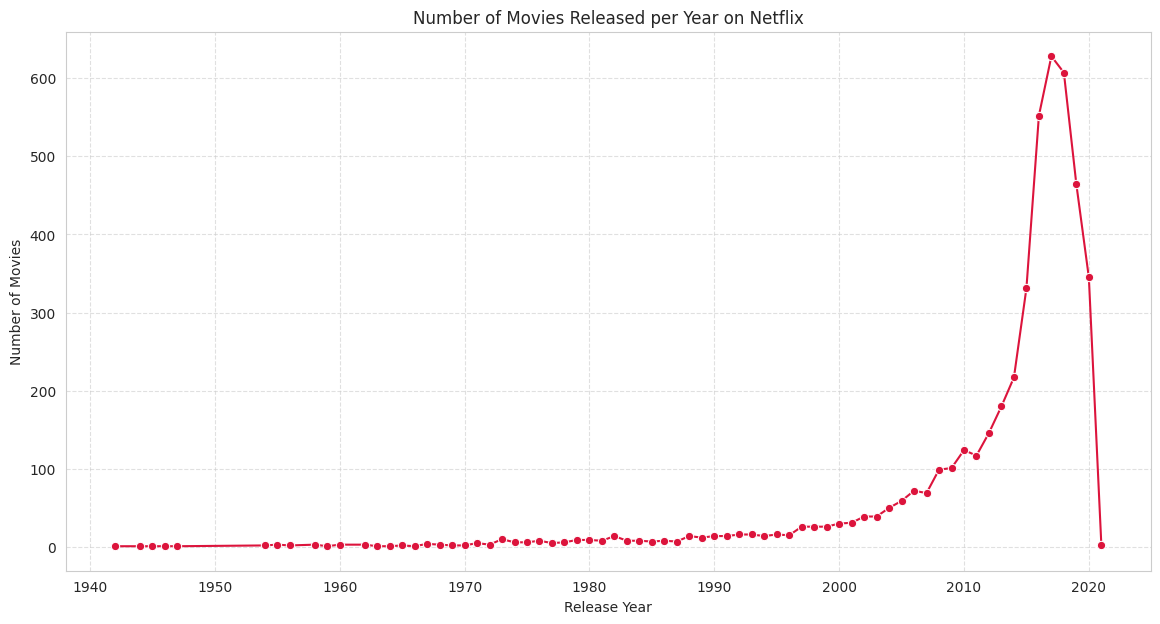

,release_year,count
66,2017,628
67,2018,607
65,2016,552
68,2019,464
69,2020,345
64,2015,331
63,2014,217
62,2013,180
61,2012,146
59,2010,124


In [72]:
# Group by release year and count movies
year_counts = all_movies['release_year'].value_counts().sort_index().reset_index()
year_counts.columns = ['release_year', 'count']

# Create the line plot
plt.figure(figsize=(14, 7))
sns.lineplot(data=year_counts, x='release_year', y='count', marker='o', color='crimson')
plt.title('Number of Movies Released per Year on Netflix')
plt.xlabel('Release Year')
plt.ylabel('Number of Movies')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Display the years with the highest production
display(year_counts.sort_values(by='count', ascending=False).head(10))